# โจทย์ที่ 1: การนับวัตถุจากภาพภายใต้ Domain Shift

## Overview

ฝ่ายตรวจสอบภาพได้รับภาพขาวดำที่ประกอบด้วยสี่เหลี่ยม สามเหลี่ยม และดาว หน้าที่ของคุณคือสร้างโมเดล CNN ด้วย PyTorch เพื่อทำนายจำนวนรูปทรงทั้งหมดในแต่ละภาพ

ข้อมูลฝึกเป็นภาพต้นฉบับที่สะอาด แต่ภาพทดสอบทั้งหมดมาจากกระบวนการสร้างภาพที่ถูกรบกวนด้วย salt-and-pepper noise, Gaussian blur หรือ motion blur ภาพพื้นฐานของชุดทดสอบไม่เคยปรากฏในชุดฝึกหรือชุดตรวจสอบมาก่อน จึงเกิด domain shift ที่ไม่สามารถแก้ได้ด้วยการจำภาพ

สามารถใช้ OpenCV สำหรับตรวจสอบภาพ ทำ preprocessing และสร้าง augmentation ได้ แต่โมเดล CNN และกระบวนการเรียนรู้ต้องสร้างด้วย PyTorch

## Description

ชุดข้อมูลต้นทางมีภาพพื้นฐานสะอาด 1,795 ภาพ แต่ละภาพมีภาพต้นฉบับหนึ่งภาพและภาพรบกวนหลายรูปแบบ การแบ่งข้อมูลทำที่ระดับ `image_id` และใช้ stratification จากช่วงของ `total_shapes` เพื่อรักษาการกระจายจำนวนวัตถุโดยประมาณ พร้อมรับประกันว่า `image_id` ไม่ซ้ำข้ามชุด

- `train.csv` และ `train_images.npz`: ภาพสะอาด 1,255 ภาพ พร้อม `total_shapes`
- `validation.csv` และ `validation_images.npz`: ภาพสะอาด 270 ภาพ พร้อม `total_shapes`
- `test.csv` และ `test_images.npz`: ภาพรบกวน 1,890 ภาพจากภาพพื้นฐานอีก 270 ภาพ โดยไม่มี `total_shapes`

ไฟล์ CSV เก็บ id และ metadata ส่วนอาร์เรย์ภาพเรียงตาม id อยู่ใน key `images` ของไฟล์ NPZ ที่มีชื่อสอดคล้องกัน ชุด train และ validation ไม่มีภาพรบกวนจากแหล่งข้อมูล ผู้ทำโจทย์จึงต้องสร้าง augmentation จากภาพสะอาดเอง หากต้องการให้โมเดลรับมือกับ noise ใน test

ชนิดของภาพรบกวนใน test ได้แก่ `salt_pepper_medium`, `salt_pepper_heavy`, `salt_pepper_extreme`, `gaussian_blur_heavy`, `gaussian_blur_extreme`, `motion_blur` และ `motion_blur_heavy`

## Public Data

โครงสร้างไฟล์ใน `data/public`:

```text
train.csv
train_images.npz
validation.csv
validation_images.npz
test.csv
test_images.npz
```

`train.csv` และ `validation.csv` มีคอลัมน์ `id`, `image_id`, `total_shapes` ส่วน `test.csv` มี `id`, `image_id`, `noise_type`, `bucket_name`, `difficulty` และไม่มี label

## Evaluation

วัดผลด้วย Mean Absolute Error บนคำตอบจำนวนวัตถุจริงของ test

```text
MAE = mean(abs(y_true - y_pred))
```

คะแนนต่ำกว่าแสดงว่าทำนายจำนวนรูปทรงได้แม่นกว่า การแบ่ง validation มีไว้สำหรับเลือก preprocessing, augmentation, architecture และ checkpoint โดยไม่ใช้คำตอบของ test

## Submission File

ส่งไฟล์ `submission_cv.csv` จำนวน 1,890 แถว

```csv
id,predicted_count
0,24
1,24
2,23
```

- `id`: ลำดับภาพใน `test_images.npz`
- `predicted_count`: จำนวนรูปทรงที่โมเดลทำนาย เป็นจำนวนเต็มไม่ติดลบ


In [1]:
import io, random, time, warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(max(1, min(8, torch.get_num_threads())))

print("device:", device)
print("torch:", torch.__version__)
print("opencv:", cv2.__version__)

device: cpu
torch: 2.14.0+cpu
opencv: 5.0.0


In [2]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
source_file = data_dir / "shape_counting.parquet"
url = "https://huggingface.co/api/datasets/nooranis/shape-counting-dataset/parquet/default/train/0.parquet"

if not source_file.exists():
    import requests
    response = requests.get(url, timeout=180)
    response.raise_for_status()
    source_file.write_bytes(response.content)

source = pd.read_parquet(source_file).reset_index(drop=True)

print("all rows:", len(source))
print("base images:", source.image_id.nunique())
print(source.noise_type.value_counts())
source[["image_id", "noise_type", "bucket_name", "difficulty", "total_shapes"]].head(10)

all rows: 14360
base images: 1795
noise_type
original               1795
salt_pepper_medium     1795
salt_pepper_heavy      1795
salt_pepper_extreme    1795
blur_heavy             1795
blur_extreme           1795
motion_blur            1795
motion_blur_heavy      1795
Name: count, dtype: int64


,image_id,noise_type,bucket_name,difficulty,total_shapes
0,0,original,single_shape,medium,11
1,0,salt_pepper_medium,single_shape,medium,11
2,0,salt_pepper_heavy,single_shape,medium,11
3,0,salt_pepper_extreme,single_shape,medium,11
4,0,blur_heavy,single_shape,medium,11
5,0,blur_extreme,single_shape,medium,11
6,0,motion_blur,single_shape,medium,11
7,0,motion_blur_heavy,single_shape,medium,11
8,1,original,single_shape,medium,11
9,1,salt_pepper_medium,single_shape,medium,11


In [3]:
originals = source[source.noise_type == "original"].reset_index(drop=True).copy()
originals["stratum"] = pd.qcut(originals.total_shapes, q=8, duplicates="drop").astype(str)

development, test_bases = train_test_split(originals, test_size=270, random_state=SEED, stratify=originals.stratum)
train_bases, val_bases = train_test_split(development, test_size=270, random_state=SEED + 1, stratify=development.stratum)

train_source = originals[originals.image_id.isin(train_bases.image_id)].reset_index(drop=True)
val_source = originals[originals.image_id.isin(val_bases.image_id)].reset_index(drop=True)
private_test = source[source.image_id.isin(test_bases.image_id) & (source.noise_type != "original")].reset_index(drop=True)
private_test_labels = private_test.total_shapes.to_numpy(np.float32)

def decode_public(item):
    return cv2.imdecode(np.frombuffer(item["bytes"], dtype=np.uint8), cv2.IMREAD_GRAYSCALE)

train_export_images = np.stack([decode_public(item) for item in train_source.image])
val_export_images = np.stack([decode_public(item) for item in val_source.image])
test_export_images = np.stack([decode_public(item) for item in private_test.image])

public_dir = data_dir / "public"
public_dir.mkdir(exist_ok=True)

train_public = train_source[["image_id", "total_shapes"]].copy()
validation_public = val_source[["image_id", "total_shapes"]].copy()
test_public = private_test[["image_id", "bucket_name", "difficulty"]].copy()
train_public.insert(0, "id", np.arange(len(train_public)))
validation_public.insert(0, "id", np.arange(len(validation_public)))
test_public.insert(0, "id", np.arange(len(test_public)))

train_public.to_csv(public_dir / "train.csv", index=False)
validation_public.to_csv(public_dir / "validation.csv", index=False)
test_public.to_csv(public_dir / "test.csv", index=False)
np.savez_compressed(public_dir / "train_images.npz", images=train_export_images)
np.savez_compressed(public_dir / "validation_images.npz", images=val_export_images)
np.savez_compressed(public_dir / "test_images.npz", images=test_export_images)

train_table = pd.read_csv(public_dir / "train.csv")
val_table = pd.read_csv(public_dir / "validation.csv")
test_table = pd.read_csv(public_dir / "test.csv")
train_clean = np.load(public_dir / "train_images.npz")["images"]
val_clean = np.load(public_dir / "validation_images.npz")["images"]
test_noisy = np.load(public_dir / "test_images.npz")["images"]

print("public files:", sorted(path.name for path in public_dir.iterdir()))
print("train:", train_table.shape, train_table.columns.tolist())
print("validation:", val_table.shape, val_table.columns.tolist())
print("test:", test_table.shape, test_table.columns.tolist())
print("test label present:", "total_shapes" in test_table.columns)
print("base id overlap:", len(set(train_table.image_id) & set(val_table.image_id)), len(set(train_table.image_id) & set(test_table.image_id)), len(set(val_table.image_id) & set(test_table.image_id)))
display(pd.crosstab(pd.cut(pd.concat([train_table.total_shapes, val_table.total_shapes]), bins=8), ["development"], normalize="columns").round(3).head())

public files: ['test.csv', 'test_images.npz', 'train.csv', 'train_images.npz', 'validation.csv', 'validation_images.npz']
train: (1255, 3) ['id', 'image_id', 'total_shapes']
validation: (270, 3) ['id', 'image_id', 'total_shapes']
test: (1890, 5) ['id', 'image_id', 'noise_type', 'bucket_name', 'difficulty']
test label present: False
base id overlap: 0 0 0


col_0,development
total_shapes,
"(10.951, 17.125]",0.184
"(17.125, 23.25]",0.174
"(23.25, 29.375]",0.222
"(29.375, 35.5]",0.111
"(35.5, 41.625]",0.119


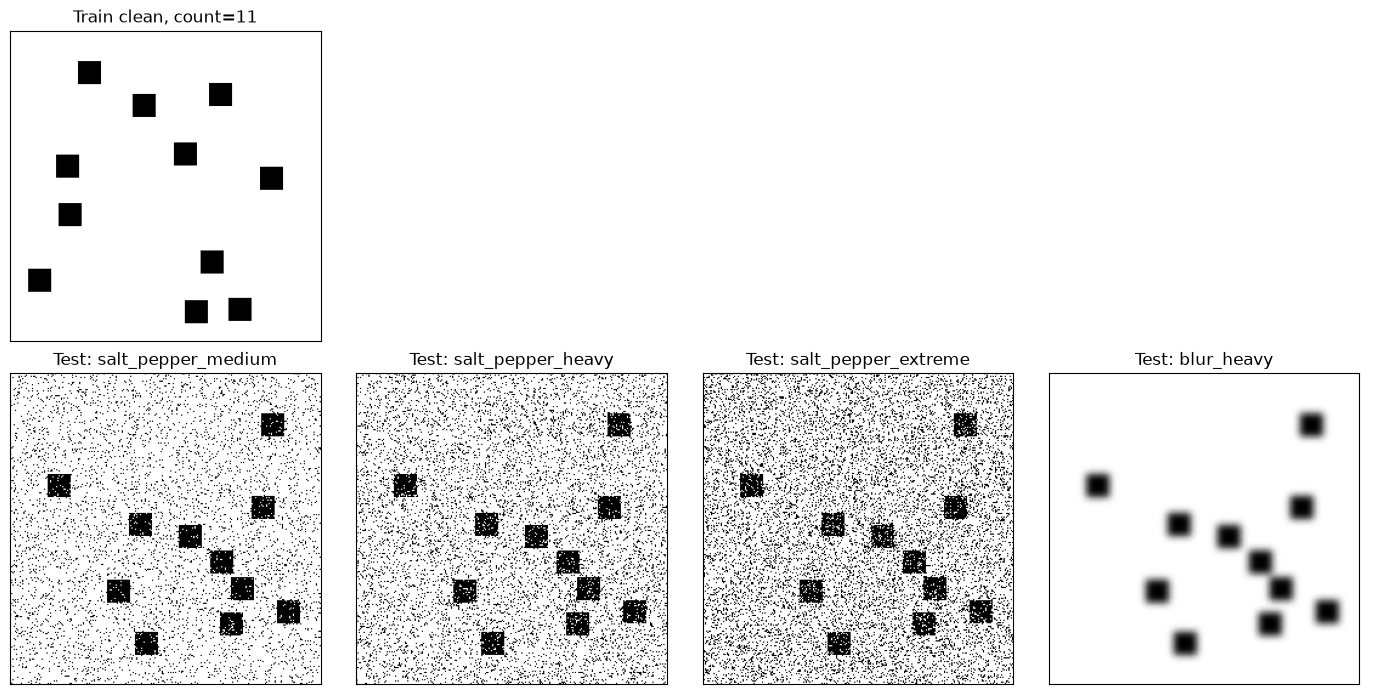

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(train_clean[0], cmap="gray")
axes[0, 0].set_title(f"Train clean, count={train_table.total_shapes.iloc[0]}")
for ax in axes[0, 1:]:
    ax.axis("off")

sample_indices = test_table.groupby("difficulty", sort=False).head(1).index[:4]
for ax, index in zip(axes[1], sample_indices):
    ax.imshow(test_noisy[index], cmap="gray")
    ax.set_title(f"Test: {test_table.difficulty.iloc[index]}")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

train images: (1255, 256, 256) uint8
validation images: (270, 256, 256)
test images: (1890, 256, 256)
test labels exposed: False


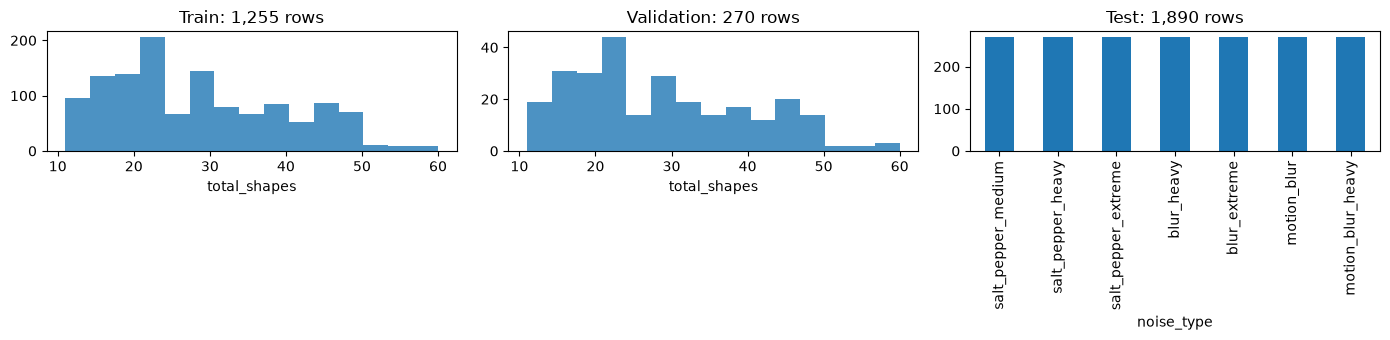

In [5]:
SIZE = 64
train_labels = train_table.total_shapes.to_numpy(np.float32)
val_labels = val_table.total_shapes.to_numpy(np.float32)

print("train images:", train_clean.shape, train_clean.dtype)
print("validation images:", val_clean.shape)
print("test images:", test_noisy.shape)
print("test labels exposed:", "total_shapes" in test_table.columns)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, frame, title in zip(axes, [train_table, val_table, test_table], ["Train", "Validation", "Test"]):
    if "total_shapes" in frame:
        ax.hist(frame.total_shapes, bins=15, alpha=.8)
        ax.set_xlabel("total_shapes")
    else:
        frame.difficulty.value_counts().plot.bar(ax=ax)
        ax.set_xlabel("difficulty")
    ax.set_title(f"{title}: {len(frame):,} rows")
plt.tight_layout()
plt.show()

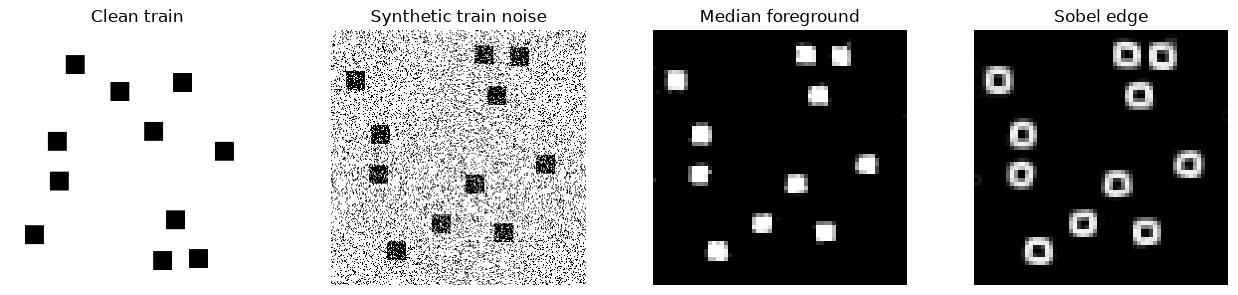

In [6]:
def corrupt(image, rng, mode=None):
    x = image.copy()
    if mode is None:
        mode = int(rng.integers(0, 8))
    if mode in [1, 2, 3]:
        probability = [0.15, 0.25, 0.35][mode - 1]
        random_map = rng.random(x.shape)
        x[random_map < probability / 2] = 0
        x[(random_map >= probability / 2) & (random_map < probability)] = 255
    if mode in [4, 5]:
        kernel = [13, 21][mode - 4]
        x = cv2.GaussianBlur(x, (kernel, kernel), 0)
    if mode in [6, 7]:
        kernel = [9, 13][mode - 6]
        motion = np.zeros((kernel, kernel), dtype=np.float32)
        motion[kernel // 2] = 1 / kernel
        x = cv2.filter2D(x, -1, motion)
    if rng.random() < 0.5:
        x = np.fliplr(x)
    if rng.random() < 0.5:
        x = np.flipud(x)
    x = np.rot90(x, int(rng.integers(0, 4)))
    return np.ascontiguousarray(x)

def preprocess(image):
    median = cv2.medianBlur(image, 5)
    resized = cv2.resize(median, (SIZE, SIZE), interpolation=cv2.INTER_AREA)
    foreground = 1 - resized.astype(np.float32) / 255
    gx = cv2.Sobel(resized, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(resized, cv2.CV_32F, 0, 1, ksize=3)
    edge = np.sqrt(gx ** 2 + gy ** 2) / 1442.5
    return np.stack([foreground, np.clip(edge, 0, 1)]).astype(np.float32)

rng = np.random.default_rng(SEED)
preview_clean = train_clean[0]
preview_noise = corrupt(preview_clean, rng, 3)
preview_channels = preprocess(preview_noise)

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, image, title in zip(axes, [preview_clean, preview_noise, preview_channels[0], preview_channels[1]], ["Clean train", "Synthetic train noise", "Median foreground", "Sobel edge"]):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
class AugmentedCleanDataset(Dataset):
    def __init__(self, images, labels, repeats=8):
        self.images = images
        self.labels = labels
        self.repeats = repeats

    def __len__(self):
        return len(self.images) * self.repeats

    def __getitem__(self, index):
        base = index % len(self.images)
        rng = np.random.default_rng(np.random.randint(0, 2 ** 31 - 1))
        image = corrupt(self.images[base], rng)
        return torch.from_numpy(preprocess(image)), torch.tensor(self.labels[base])

class RobustValidationDataset(Dataset):
    def __init__(self, images, labels, variants=8):
        self.images = images
        self.labels = labels
        self.variants = variants

    def __len__(self):
        return len(self.images) * self.variants

    def __getitem__(self, index):
        base = index % len(self.images)
        mode = index // len(self.images)
        rng = np.random.default_rng(SEED * 100000 + index)
        image = corrupt(self.images[base], rng, mode)
        return torch.from_numpy(preprocess(image)), torch.tensor(self.labels[base])

class UnlabeledTestDataset(Dataset):
    def __init__(self, images):
        self.tensor = torch.from_numpy(np.stack([preprocess(image) for image in images]))

    def __len__(self):
        return len(self.tensor)

    def __getitem__(self, index):
        return self.tensor[index]

train_loader = DataLoader(AugmentedCleanDataset(train_clean, train_labels), batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(RobustValidationDataset(val_clean, val_labels), batch_size=512, shuffle=False, num_workers=0)
test_loader = DataLoader(UnlabeledTestDataset(test_noisy), batch_size=512, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
test_batch = next(iter(test_loader))
print("train batch:", xb.shape, yb.shape)
print("test batch:", test_batch.shape)

train batch: torch.Size([256, 2, 64, 64]) torch.Size([256])
test batch: torch.Size([512, 2, 64, 64])


In [8]:
class CountCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 24, 5, padding=2), nn.BatchNorm2d(24), nn.SiLU(),
            nn.Conv2d(24, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.SiLU(),
            nn.Conv2d(32, 48, 3, stride=2, padding=1), nn.BatchNorm2d(48), nn.SiLU(),
            nn.Conv2d(48, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.SiLU(),
            nn.Conv2d(64, 96, 3, stride=2, padding=1), nn.BatchNorm2d(96), nn.SiLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.head = nn.Sequential(nn.Linear(98, 64), nn.SiLU(), nn.Dropout(.10), nn.Linear(64, 1))

    def forward(self, x):
        features = self.features(x).flatten(1)
        statistics = x.mean(dim=(2, 3))
        return self.head(torch.cat([features, statistics], dim=1)).squeeze(1)

model = CountCNN().to(device)
print(model)
print("parameters:", sum(parameter.numel() for parameter in model.parameters()))
print("output shape:", model(xb[:4].to(device)).shape)

CountCNN(
  (features): Sequential(
    (0): Conv2d(2, 24, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Conv2d(24, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): SiLU()
    (6): Conv2d(32, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): SiLU()
    (9): Conv2d(48, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): SiLU()
    (12): Conv2d(64, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (14): SiLU()
    (

In [9]:
target_mean = float(train_labels.mean())
target_std = float(train_labels.std())
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=.5, patience=2)

history = []
best_mae = float("inf")
best_state = None
patience = 0

for epoch in range(1, 21):
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        prediction = model(x)
        loss = F.smooth_l1_loss(prediction, (y - target_mean) / target_std, beta=.35)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        optimizer.step()
        total_loss += loss.item() * len(y)

    model.eval()
    predictions, truths = [], []
    with torch.no_grad():
        for x, y in val_loader:
            prediction = model(x.to(device)).cpu() * target_std + target_mean
            predictions.append(prediction)
            truths.append(y)
    val_prediction = torch.cat(predictions).numpy()
    val_truth = torch.cat(truths).numpy()
    val_mae = mean_absolute_error(val_truth, val_prediction)
    train_loss = total_loss / len(train_loader.dataset)
    history.append((epoch, train_loss, val_mae))
    scheduler.step(val_mae)

    if val_mae < best_mae - .01:
        best_mae = val_mae
        best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        patience = 0
    else:
        patience += 1

    print(f"epoch={epoch:02d} train_loss={train_loss:.4f} robust_val_mae={val_mae:.3f} lr={optimizer.param_groups[0]['lr']:.1e}")
    if patience >= 5 and epoch >= 10:
        break

model.load_state_dict(best_state)
print("best robust validation MAE:", round(best_mae, 4))

epoch=01 train_loss=0.0870 robust_val_mae=1.609 lr=2.0e-03


epoch=02 train_loss=0.0161 robust_val_mae=1.307 lr=2.0e-03


epoch=03 train_loss=0.0173 robust_val_mae=2.295 lr=2.0e-03


epoch=04 train_loss=0.0146 robust_val_mae=1.086 lr=2.0e-03


epoch=05 train_loss=0.0177 robust_val_mae=0.831 lr=2.0e-03


...

epoch=08 train_loss=0.0107 robust_val_mae=1.635 lr=2.0e-03


epoch=09 train_loss=0.0148 robust_val_mae=2.115 lr=2.0e-03


epoch=10 train_loss=0.0162 robust_val_mae=1.399 lr=1.0e-03


epoch=11 train_loss=0.0147 robust_val_mae=1.119 lr=1.0e-03


epoch=12 train_loss=0.0114 robust_val_mae=0.708 lr=1.0e-03
best robust validation MAE: 0.542


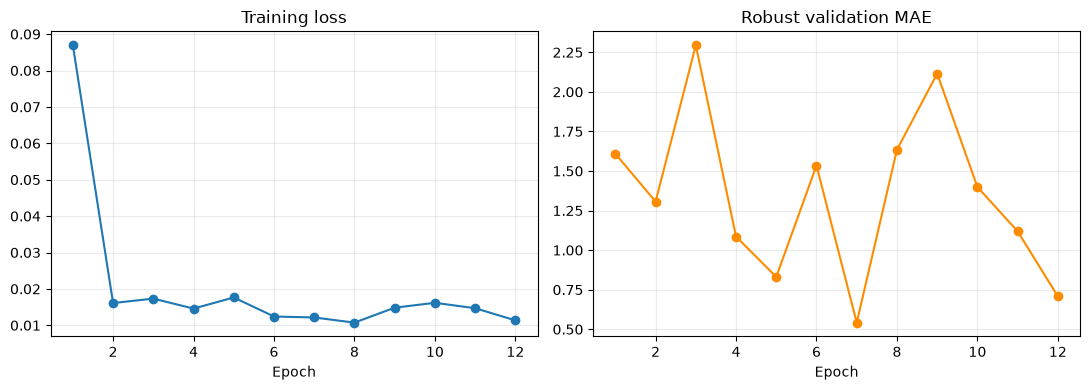

In [10]:
history_df = pd.DataFrame(history, columns=["epoch", "train_loss", "robust_validation_mae"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df.epoch, history_df.train_loss, marker="o")
axes[1].plot(history_df.epoch, history_df.robust_validation_mae, marker="o", color="darkorange")
axes[0].set_title("Training loss")
axes[1].set_title("Robust validation MAE")
for ax in axes:
    ax.grid(alpha=.25)
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

In [11]:
model.eval()
test_predictions = []
with torch.no_grad():
    for x in test_loader:
        prediction = model(x.to(device)).cpu() * target_std + target_mean
        test_predictions.append(prediction)
test_prediction = torch.cat(test_predictions).numpy()

submission = pd.DataFrame({"id": np.arange(len(test_prediction)), "predicted_count": np.rint(test_prediction).clip(11, 60).astype(int)})
submission.to_csv("submission_cv.csv", index=False)

print("public test table:", test_table.shape)
print("label columns in public test:", [column for column in test_table.columns if "count" in column])
print("submission:", submission.shape)
submission.head(10)

public test table: (1890, 5)
label columns in public test: []
submission: (1890, 2)


,id,predicted_count
0,0,12
1,1,12
2,2,13
3,3,12
4,4,13
5,5,12
6,6,12
7,7,16
8,8,16
9,9,16


In [12]:
mae = mean_absolute_error(private_test_labels, test_prediction)
rmse = mean_squared_error(private_test_labels, test_prediction) ** .5
r2 = r2_score(private_test_labels, test_prediction)
within_1 = np.mean(np.abs(test_prediction - private_test_labels) <= 1)
within_2 = np.mean(np.abs(test_prediction - private_test_labels) <= 2)
rounded_exact = np.mean(submission.predicted_count.to_numpy() == private_test_labels)

print(f"private test MAE={mae:.3f}")
print(f"private test RMSE={rmse:.3f}")
print(f"private test R2={r2:.4f}")
print(f"within 1={within_1:.2%}")
print(f"within 2={within_2:.2%}")
print(f"rounded exact={rounded_exact:.2%}")

scored = private_test[["noise_type", "difficulty"]].copy()
scored["true"] = private_test_labels
scored["prediction"] = test_prediction
scored["absolute_error"] = np.abs(scored.true - scored.prediction)
display(scored.groupby("noise_type").absolute_error.agg(["count", "mean", "median", "max"]).sort_values("mean").round(3))

private test MAE=0.667
private test RMSE=0.895
private test R2=0.9939
within 1=79.79%
within 2=96.93%
rounded exact=46.93%


,count,mean,median,max
noise_type,,,,
motion_blur_heavy,270,0.491,0.416,2.288
blur_heavy,270,0.531,0.467,2.527
motion_blur,270,0.547,0.440,2.318
salt_pepper_medium,270,0.552,0.497,2.213
salt_pepper_heavy,270,0.560,0.506,2.424
salt_pepper_extreme,270,0.620,0.554,2.316
blur_extreme,270,1.368,1.236,7.144


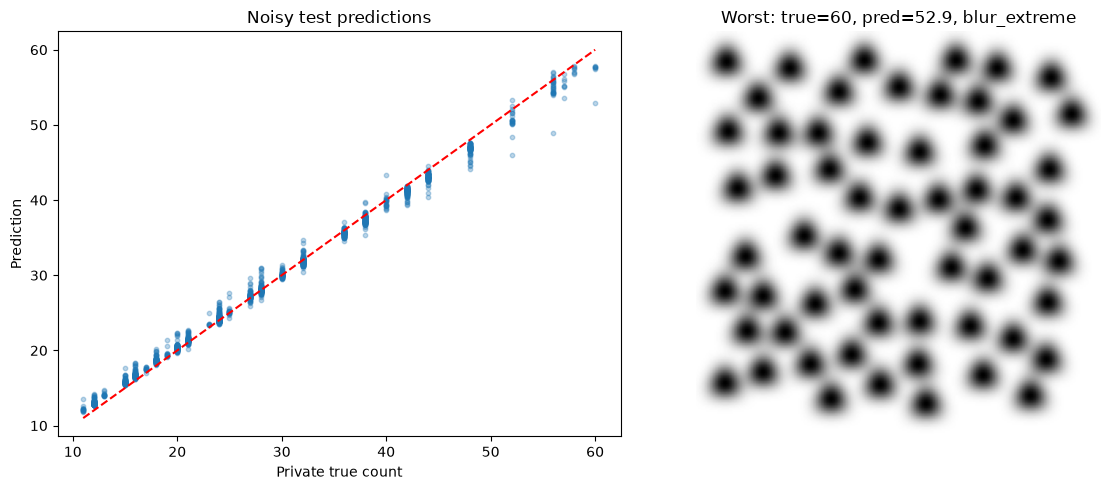

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(private_test_labels, test_prediction, s=10, alpha=.30)
axes[0].plot([11, 60], [11, 60], "r--")
axes[0].set_xlabel("Private true count")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Noisy test predictions")

worst = int(np.argmax(np.abs(test_prediction - private_test_labels)))
axes[1].imshow(test_noisy[worst], cmap="gray")
axes[1].set_title(f"Worst: true={private_test_labels[worst]:.0f}, pred={test_prediction[worst]:.1f}, {private_test.iloc[worst].noise_type}")
axes[1].axis("off")
plt.tight_layout()
plt.show()